# TP2 PROCESAMIENTO DEL HABLA

**Escriba aquí su nombre completo.**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.




## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [1]:
# Se instalan las librerias necesarias
!pip install requests beautifulsoup4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 7.0 MB/s eta 0:00:00


In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://abe.cl/documento-jobs.html"
respuesta = requests.get(url)
soup = BeautifulSoup(respuesta.text, "html.parser")

# Extraer todos los párrafos
parrafos = soup.find_all("p")

# Quitar el primero y el último
parrafos_discurso = parrafos[2]

# Concatenar el texto
texto_jobs = " ".join([p.get_text() for p in parrafos_discurso])

print("Cantidad de párrafos del discurso:", len(parrafos_discurso))
print(texto_jobs)


Cantidad de párrafos del discurso: 2

 
	Tengo el honor de estar hoy aquí con ustedes en su comienzo en una
	de las mejores universidades del mundo. La verdad sea dicha, yo nunca me
	gradué. En realidad, esto es lo más cerca que jamás
	he estado de una graduación universitaria. Hoy les quiero contar tres
	historias de mi vida. Nada especial. Sólo tres historias.
	
	  La primera historia versa sobre "conectar los puntos".
	

	Dejé la Universidad de Reed tras los seis primeros meses, pero
	después seguí vagando por allí otros 18 meses, más
	o menos, antes de dejarlo del todo. Entonces, ¿por qué lo dejé?
	
	Comenzó antes de que yo naciera. Mi madre biológica era una
	estudiante joven y soltera, y decidió darme en adopción. Ella
	tenía muy claro que quienes me adoptaran tendrían que ser titulados
	universitarios, de modo que se preparó todo para que al nacer fuese
	adoptado por un abogado y su mujer. Solo que cuando yo nací decidieron
	a último momento que lo que de verdad querían era una 

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [3]:
!pip uninstall -y nltk
!pip install nltk


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 885.9 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 20.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.6 MB/s eta 0:00:00


In [4]:
import nltk
from nltk.corpus import stopwords
import re

# Descargar stopwords en NLTK
nltk.download("stopwords")

# Lista de stopwords en español
stop_words = set(stopwords.words("spanish"))

# Tokenizar el texto en palabras (solo letras, sin signos)
tokens = re.findall(r"\b\w+\b", texto_jobs.lower()) #\b → marca un límite de palabra (inicio o fin).
                                                    # \w+ → significa “una o más letras, números o guiones bajos”. En este caso, captura palabras completas.
                                                    # \b → asegura que la coincidencia termine justo en el límite de la palabra.

# filtrar las stopwords que aparecen en el texto
stopwords_en_texto = sorted(set([t for t in tokens if t in stop_words]))
# sorted(...) Ordena el conjunto alfabeticamente y lo devuelve como lista
# set(...) Convierte esa lista en un conjunto, los conjuntos eliminan duplicados automaticamente

print("Stopwords encontradas en el discurso:")
print(stopwords_en_texto)


[nltk_data] Downloading package stopwords to /home/pablo/nltk_data...


Stopwords encontradas en el discurso:
['a', 'al', 'algo', 'algunas', 'algunos', 'antes', 'como', 'con', 'cuando', 'de', 'del', 'desde', 'durante', 'e', 'el', 'ella', 'ellos', 'en', 'entre', 'era', 'eran', 'es', 'esa', 'ese', 'eso', 'esta', 'estaba', 'estaban', 'estado', 'estar', 'esto', 'estoy', 'estábamos', 'estás', 'esté', 'fue', 'fuera', 'fueron', 'fuese', 'fui', 'ha', 'habiendo', 'habría', 'había', 'habíamos', 'habían', 'han', 'has', 'hasta', 'hay', 'haya', 'hayan', 'he', 'hubiera', 'hubieran', 'la', 'las', 'le', 'les', 'lo', 'los', 'me', 'mi', 'mis', 'mucho', 'muy', 'más', 'mí', 'nada', 'ni', 'no', 'nos', 'nosotros', 'nuestra', 'o', 'otra', 'otro', 'otros', 'para', 'pero', 'poco', 'por', 'porque', 'que', 'quienes', 'qué', 'se', 'sea', 'sería', 'sin', 'sobre', 'son', 'su', 'sus', 'tanto', 'te', 'tendrás', 'tendrían', 'tenemos', 'tengan', 'tengo', 'tenido', 'tenía', 'tiene', 'tienen', 'tienes', 'todo', 'todos', 'tu', 'tus', 'tuve', 'tuviera', 'tú', 'un', 'una', 'uno', 'unos', 'y', '

[nltk_data]   Unzipping corpora/stopwords.zip.


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

In [6]:
!pip install wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 6.7 MB/s eta 0:00:0000:0100:01


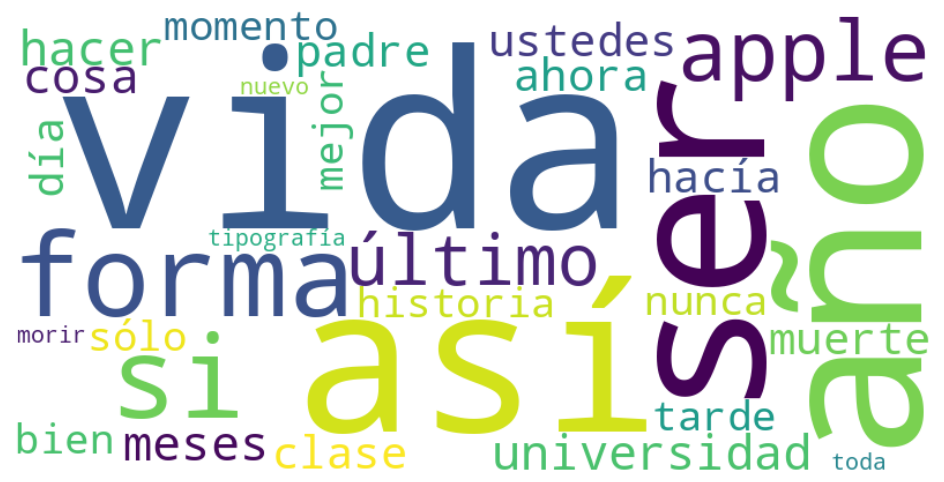

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtrar tokens que no sean stopwords
tokens_sin_stopwords = [t for t in tokens if t not in stop_words]

# Unir las palabras en un solo string
texto_limpio = " ".join(tokens_sin_stopwords)

# Crear nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=30, colormap="viridis").generate(texto_limpio)

# Mostrar la nube
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [10]:
!pip install scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 23.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 25.6 MB/s eta 0:00:0000:0100:01


In [11]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Descargar recursos necesarios
nltk.download("punkt")
nltk.download("punkt_tab")

# Pasar Stop_words de set a lista
stop_words = list(stopwords.words("spanish"))

# Dividir oraciones
oraciones_crudas = sent_tokenize(texto_jobs, language="spanish")

# Limpiar las oraciones
oraciones = [re.sub(r"[^a-zA-Záéíóúñü\s]", "", o.lower()) for o in oraciones_crudas]

# Matriz documento-vocabulario
vectorizer = CountVectorizer(stop_words=stop_words)
X = vectorizer.fit_transform(oraciones)

# Convertir a DataFrame
matriz = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())


print("Primeras 5 oraciones:")
print(oraciones[:5])
print("\nMatriz documento-vocabulario (primeras filas):")
print(matriz.head())
print("La matriz es de:")
print(matriz.shape)

# Descargar la matriz en formato CSV
'''matriz.to_csv("matriz_documento_vocabulario.csv", index=False)'''


[nltk_data] Downloading package punkt to /home/pablo/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/pablo/nltk_data...


Primeras 5 oraciones:
['\n \n\ttengo el honor de estar hoy aquí con ustedes en su comienzo en una\n\tde las mejores universidades del mundo', 'la verdad sea dicha yo nunca me\n\tgradué', 'en realidad esto es lo más cerca que jamás\n\the estado de una graduación universitaria', 'hoy les quiero contar tres\n\thistorias de mi vida', 'nada especial']

Matriz documento-vocabulario (primeras filas):
   abogado  abrirse  aconsejó  acontecimientos  actual  actuar  adelante  \
0        0        0         0                0       0       0         0   
1        0        0         0                0       0       0         0   
2        0        0         0                0       0       0         0   
3        0        0         0                0       0       0         0   
4        0        0         0                0       0       0         0   

   adiós  adopción  adoptado  ...  woz  zanjados  ápice  época  éxito  última  \
0      0         0         0  ...    0         0      0      0   

[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


'matriz.to_csv("matriz_documento_vocabulario.csv", index=False)'


#### 2.3.2 Determina la longitud de tu vocabulario.

In [12]:
print("La cantidad de palabras del vocabulario son:")
print(len(vectorizer.get_feature_names_out()))

La cantidad de palabras del vocabulario son:
684



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Aplicar TF-IDF sobre las oraciones ya limpias
tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words)
X_tfidf = tfidf_vectorizer.fit_transform(oraciones)

# Convertir a DataFrame
matriz_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("Primeras 5 oraciones (limpias):")
print(oraciones[:5])
print("\nMatriz TF-IDF (primeras filas):")
print(matriz_tfidf.head())

# Descargar la matriz en formato CSV
'''matriz_tfidf.to_csv("matriz_tf-idf.csv", index=False)'''



Primeras 5 oraciones (limpias):
['\n \n\ttengo el honor de estar hoy aquí con ustedes en su comienzo en una\n\tde las mejores universidades del mundo', 'la verdad sea dicha yo nunca me\n\tgradué', 'en realidad esto es lo más cerca que jamás\n\the estado de una graduación universitaria', 'hoy les quiero contar tres\n\thistorias de mi vida', 'nada especial']

Matriz TF-IDF (primeras filas):
   abogado  abrirse  aconsejó  acontecimientos  actual  actuar  adelante  \
0      0.0      0.0       0.0              0.0     0.0     0.0       0.0   
1      0.0      0.0       0.0              0.0     0.0     0.0       0.0   
2      0.0      0.0       0.0              0.0     0.0     0.0       0.0   
3      0.0      0.0       0.0              0.0     0.0     0.0       0.0   
4      0.0      0.0       0.0              0.0     0.0     0.0       0.0   

   adiós  adopción  adoptado  ...  woz  zanjados  ápice  época  éxito  última  \
0    0.0       0.0       0.0  ...  0.0       0.0    0.0    0.0    0.0 

'matriz_tfidf.to_csv("matriz_tf-idf.csv", index=False)'

# Conclusiones del Trabajo Práctico

## 1. Webscraping
El trabajo práctico permitió comprobar la utilidad del **webscraping** como técnica de extracción de información desde páginas web. Para ello se emplearon las librerías **requests** y **beautifulsoup4**, que posibilitaron la obtención del código HTML y su posterior análisis estructurado. Esta etapa fue fundamental para disponer del discurso textual sobre el cual se aplicaron los procesos de análisis posteriores. Se concluye que el webscraping constituye una herramienta eficaz para la recolección de datos en proyectos de minería de texto y procesamiento de lenguaje natural.

---

## 2. Preprocesamiento
El preprocesamiento del corpus se realizó mediante un conjunto de librerías que permitieron limpiar, segmentar y organizar la información:

- **[NLTK]**: se utilizó para la tokenización de oraciones (sent_tokenize) y la gestión de stopwords en español.  
- **`re`**: permitió aplicar expresiones regulares para eliminar caracteres no deseados y normalizar el texto.  
- **`stopwords`**: se emplearon para filtrar palabras de alta frecuencia que no aportan significado relevante.  
- **`wordcloud`** y **`matplotlib.pyplot`**: facilitaron la visualización de las palabras más frecuentes en el discurso.  
- **`pandas`**: se usó para organizar los datos en estructuras tabulares (DataFrames).  
- **`sklearn`**: se aplicó para construir la matriz documento‑vocabulario mediante CountVectorizer.

El proceso de preprocesamiento permitió comprender la importancia del orden de las operaciones: primero segmentar en oraciones y luego limpiar cada una. Asimismo, se evidenció que las matrices generadas son naturalmente **dispersas**, con predominio de valores nulos, lo cual es característico en el análisis de texto.

---

## 3. Representación del texto
La construcción de la **[matriz documento‑vocabulario]** permitió representar cada oración como un vector de frecuencias de palabras. Se determinó que el vocabulario del discurso estaba compuesto por **684 términos únicos**, lo que refleja la riqueza léxica del discurso analizado.  

Posteriormente, se aplicó el modelo **[TF‑IDF]**, que pondera las palabras según su frecuencia en cada documento y su rareza en el corpus completo. Esta técnica permitió identificar términos distintivos y relevantes, evitando que las palabras comunes dominaran el análisis. Se concluye que TF‑IDF constituye una mejora sustancial respecto al conteo bruto de palabras, ya que aporta una medida más informativa de la importancia de cada término.

---

## Conclusión General
El trabajo práctico permitió recorrer de manera integral el flujo de un proyecto de procesamiento de lenguaje natural: desde la **extracción de datos mediante webscraping**, pasando por el **preprocesamiento y limpieza del discurso**, hasta la **representación vectorial con CountVectorizer y TF‑IDF**.  

Se concluye que, aunque las matrices generadas presentan una alta proporción de ceros, estas constituyen la base para aplicar técnicas avanzadas de análisis como **[clasificación de textos]**, **[clustering de documentos]** y **[modelado de tópicos]**. El trabajo realizado no solo tuvo un valor pedagógico, sino que también proporcionó herramientas prácticas aplicables en proyectos reales de minería de texto, análisis de sentimientos y sistemas de recuperación de información.
